#### Problem Statement ; 
#### A telecommunictions company wants to reduce customer churn by identifying customers at risk of leaving . They have historical data on customer behaviour and want to build a model to predict which customers are most likely to churn.

In [2]:
# Step - 1 : Importing Require Libraries 
import pandas as pd  # for data manipulation 
import numpy as np   # for numerical operation
import matplotlib.pyplot as plt # for basic Plotting 
import seaborn as sns # for better and cleaner visualizations 

# Splitting data into training and testing sets 
from sklearn.model_selection import train_test_split

# Converting categorical text into numbers 
from sklearn.preprocessing import LabelEncoder , StandardScaler

# Support Vector Machine model for classification 
from sklearn.svm import SVC

# Metrics to evaluate model performance 
from sklearn.metrics import(
    accuracy_score ,       # Overall accuracy
    classification_report, # Precision , Recall , F1-score 
    confusion_matrix ,     # Correct Vs wrong predictions 
    roc_auc_score,         # Class separation score 
    roc_curve              # ROC curve plotting 
) 

In [3]:
# Step 2 : Loading Dataset 
df = pd.read_csv("customer_churn_clean.csv")

# showing five rows from the dataset 
print("First 5 Rows of Dataset : ")
print(df.head())

First 5 Rows of Dataset : 
  customerID  tenure  MonthlyCharges  TotalCharges        Contract  \
0       C001       1           29.85         29.85  Month-to-month   
1       C002      34           56.95       1889.50        One year   
2       C003       2           53.85        108.15  Month-to-month   
3       C004      45           42.30       1840.75        Two year   
4       C005       5           70.70        353.50  Month-to-month   

  InternetService TechSupport     PaymentMethod Churn  
0             DSL          No  Electronic check   Yes  
1     Fiber optic         Yes     Bank transfer    No  
2             DSL          No  Electronic check   Yes  
3     Fiber optic         Yes       Credit card    No  
4     Fiber optic          No  Electronic check   Yes  


In [4]:
# Step 3 : Data Understanding 

# Printing dataset shape (rows , columns)
print("\nDataset Shape :", df.shape)

# Displaying dataset info (column , data types , non-null values )
print("\nDataset Infromation : ")
df.info()

# Checking missing values in each column 
print("\nMissing Values:")
print(df.isnull().sum())

#Checking duplication rows in the dataset 
print("\nDuplicate Rows : " , df.duplicated().sum())

# showing statistical summary of data 
print("\nStatistical Summary : ")
print(df.describe(include="all"))


Dataset Shape : (20, 9)

Dataset Infromation : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       20 non-null     object 
 1   tenure           20 non-null     int64  
 2   MonthlyCharges   20 non-null     float64
 3   TotalCharges     20 non-null     float64
 4   Contract         20 non-null     object 
 5   InternetService  20 non-null     object 
 6   TechSupport      20 non-null     object 
 7   PaymentMethod    20 non-null     object 
 8   Churn            20 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.5+ KB

Missing Values:
customerID         0
tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
TechSupport        0
PaymentMethod      0
Churn              0
dtype: int64

Duplicate Rows :  0

Statistical Summary : 
       customerID

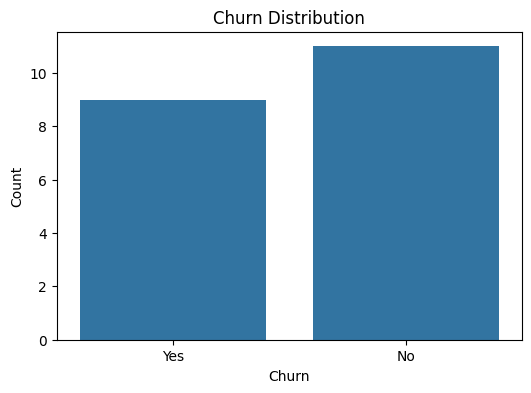

In [5]:
# Step 4 :  Churn Distibution

# Creating a figure for the plot 
plt.figure(figsize=(6,4))

# Plotting count of churn Vs non-churn customers
sns.countplot(x="Churn" , data=df)

# Adding title to the chart 
plt.title("Churn Distribution")

# Label for x-axis 
plt.xlabel("Churn")

# Label for y-axis 
plt.ylabel("Count")

# Save fig images 
plt.savefig("images/Churn Distribution.png")

# displaying the plot 
plt.show()

In [10]:
print(df.columns.tolist())

['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'TechSupport', 'PaymentMethod', 'Churn']


In [ ]:
# Step 5 : Data Preprocessing

# Clean column names
df.columns = df.columns.str.strip()

# Store encoders
label_encoders = {}

# Categorical columns
categorical_columns = [
    "Contract",
    "InternetService",
    "TechSupport",
    "PaymentMethod",
    "Churn"
]

# Encoding
for col in categorical_columns:
    
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Preview
print("\nEncoded Dataset Preview:")
print(df.head())


Encoded Dataset Preview:
   tenure  MonthlyCharges  TotalCharges  Contract  InternetService  \
0       1           29.85         29.85         0                0   
1      34           56.95       1889.50         1                1   
2       2           53.85        108.15         0                0   
3      45           42.30       1840.75         2                1   
4       5           70.70        353.50         0                1   

   TechSupport  PaymentMethod  Churn  
0            0              2      1  
1            1              0      0  
2            0              2      1  
3            1              1      0  
4            0              2      1  


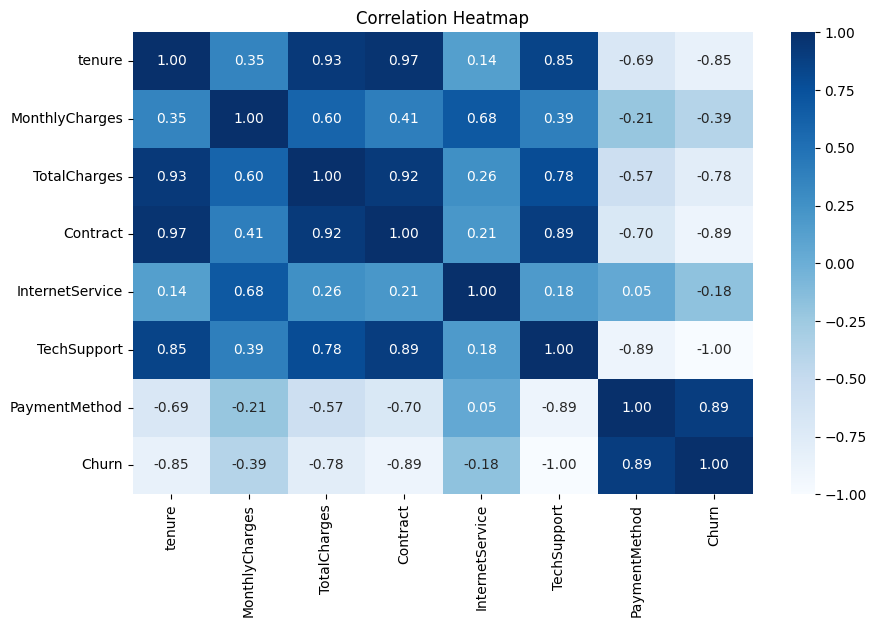

In [12]:
# Step 6 : Correlation Heatmap 

# Creating a figure for the heatmap 
plt.figure(figsize=(10,6))

# Plotting correlation between all features
sns.heatmap(df.corr() , annot= True , cmap = "Blues" , fmt = ".2f")

# Adding title to the heatmap 
plt.title("Correlation Heatmap")

# Save the heatmap 
plt.savefig("images/Correlation Heatmap.png")

# Displaying the heatmap 
plt.show()

In [13]:
# Step 7 : Define Features and Target 

# Selecting input features (all columns except "Churn")
x = df.drop("Churn" , axis= 1)

# Selecting target variable (what we want to predict )
y = df["Churn"]

In [14]:
# Step 8 : Scaling 

# Creating a scaler object to standardize feature values
scaler = StandardScaler()

# Scaling all feature values to the same range 
X_scaled = scaler.fit_transform(x)


In [15]:
# Step 8 : Train - Test Split 

# Splitting data into training and testing sets 
X_train , X_test , y_train , y_test = train_test_split(
    X_scaled,     # Scaled features 
    y,            # Target variable 
    test_size=0.2,# 20% data for testing 
    random_state=42,# Ensures reproducibility
    stratify= y   # Maintains class balance in split 
)

# Printing shape of training data 
print("\nTrain Shape :",X_train.shape)

# Printing shape of testing data 
print("Test Shape : ",X_test.shape)



Train Shape : (16, 7)
Test Shape :  (4, 7)


In [17]:
# Step 9 : Model Training using SVM

# Creating SVM model with RBF karnel 
model = SVC(
    kernel= "rbf" ,   # Non - Linear decision boundary
    probability=True, # Enables probability predictions 
    random_state=42  # for consistent results 
)
# Training the model on training data 
model.fit(X_train , y_train)

SVC(probability=True, random_state=42)

In [18]:
# Step 10 : Model Prediction 

# Generate predicted class labels (0 or 1)
y_pred = model.predict(X_test)

# Generate predicted probabilities for the positive class (Churn= 1)
y_prob = model.predict_proba(X_test)[:,1]



In [19]:
# Step 11 : Model Evalution 

# Calculate overall accuracy of the model 
accuracy = accuracy_score(y_test , y_pred)
print("\nAccuracy Score : " , accuracy)

# Print detailed classification metrics (percision , recall , F1-score)
print("\nClassification Report : ")
print(classification_report(y_test , y_pred))


Accuracy Score :  1.0

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



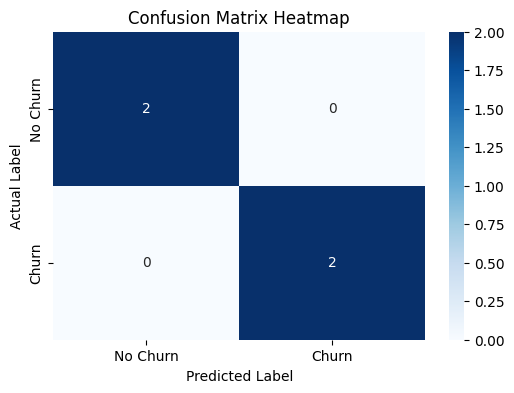

In [22]:
# Step 12 : confusion Matrix Heatmap 

# Compute confusion matrix to evalute prediction performance 
cm = confusion_matrix(y_test , y_pred)

# Create heatmap visualization for cunfusion matrix 
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm , 
    annot=True , # Show numbers inside cells 
    fmt = "d", # format numbers as integers
    cmap= "Blues", # color theme 
    xticklabels=["No Churn" , "Churn"], # Predicted labels
    yticklabels=["No Churn" , "Churn"]  # Actual labels
)

# Add title and axis labels for clarity 
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("images/Confusion Matrix Heatmap.png")

# Display the plot 
plt.show()

In [23]:
# Step 13 : ROC - AOC Score 
# Calculate ROC - AOC score to measure model's ability to distinguish between classes
roc_auc = roc_auc_score(y_test , y_pred)

# print ROC-AUC score 
print("\nROC- AUC Score : " , roc_auc)


ROC- AUC Score :  1.0


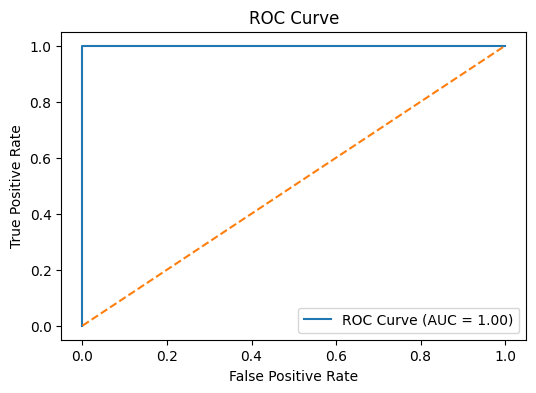

In [24]:
# Step 14 : ROC Cureve 
# compute False Positive Rate (FPR) True Positive Rate (TPR) and thresholds
fpr , tpr , thresholds = roc_curve(y_test , y_pred)

# Create a plot for ROC Curve 
plt.figure(figsize=(6,4))

# Plot ROC curve using FPR and TPR values 
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.2f})")

# Plot diagonal line representing random model performance 
plt.plot([0,1],[0,1] , linestyle="--")

# Add title to the plot 
plt.title("ROC Curve")

# Label X-axis as False Positive Rate
plt.xlabel("False Positive Rate")

# Label y-axis as True Positive Rate 
plt.ylabel("True Positive Rate")

# Display Legend with AUC value 
plt.legend()

# Save figure 
plt.savefig("images/ROC Curve Line.png")

# Show the plot 
plt.show()

### **Final Conclusion :**
- This project focused on predicting customer churn for a telecom company using an SVM classifier. 
- I performed data understanding, preprocessing, label encoding, feature scaling, model training, and evaluation using accuracy, classification report, confusion matrix, and ROC-AUC. The final outcome shows how machine learning can help businesses identify customers at risk of leaving and improve retention strategies. 